In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random

import torch.nn as nn
from sklearn.metrics import mean_squared_error, r2_score

import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from models import NeuronLSTM

# ── Load data ──────────────────────────────────────────────────────────────
base = "./outputs/glm_input_data/"

beh_vals = np.load(os.path.join(base, "behavior_glm_input.npy"), allow_pickle=True)
beh_idx  = np.load(os.path.join(base, "behavior_glm_input_index.npy"), allow_pickle=True)
beh_cols = np.load(os.path.join(base, "behavior_glm_input_columns.npy"), allow_pickle=True)

spk_vals = np.load(os.path.join(base, "fr_full.npy"))
spk_idx  = np.load(os.path.join(base, "fr_full_index.npy"), allow_pickle=True)
spk_cols = np.load(os.path.join(base, "fr_full_columns.npy"), allow_pickle=True)

try:
    beh_index = pd.MultiIndex.from_tuples(beh_idx, names=behavior_glm_input.index.names)
except Exception:
    beh_index = pd.Index(beh_idx)

try:
    spk_index = pd.MultiIndex.from_tuples(spk_idx, names=fr_first7.index.names)
except Exception:
    spk_index = pd.Index(spk_idx)

behavior_glm_loaded = pd.DataFrame(beh_vals, index=beh_index, columns=beh_cols)
spikes_loaded       = pd.DataFrame(spk_vals, index=spk_index, columns=spk_cols)

print("behavior_glm_loaded shape", behavior_glm_loaded.shape)
print("spikes_loaded shape",       spikes_loaded.shape)

behavior_glm_loaded shape (1333016, 29)
spikes_loaded shape (1333016, 77)


In [2]:
# ── Preprocessing (identical to MLP notebook) ──────────────────────────────
spikes_loaded.index = pd.MultiIndex.from_tuples(
    spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
)

spikes_unique_trials = set(idx[0] for idx in spikes_loaded.index)
behavior_glm_loaded  = behavior_glm_loaded[
    behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)
]

non_nan_rows        = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
spikes_loaded       = spikes_loaded.loc[non_nan_rows]

behavior_glm_loaded = behavior_glm_loaded.drop("track_zone", axis=1)

session_ids = behavior_glm_loaded.index.map(lambda x: x[0]).unique()
print(f"{len(session_ids)} sessions")

29 sessions


In [3]:
# ── Feature columns (identical to MLP notebook) ────────────────────────────
action_enc_cols = [
    'frame_raw_500msMedian',
    'frame_YawPitch_abs_vel_sum_500msMedian',
    'upcoming_choice',
    'reward_window',
    'frame_raw_abs_acc_500msMedian',
    'frame_YawPitch_abs_acc_sum_500msMedian',
    'forward_vs_rotation_corr',
    'head_angle',
    'head_angle_vel',
    'movement_energy_smooth5',
    'lick_detected',
]

In [4]:
# ── Build session dataset (identical to MLP notebook) ──────────────────────
session_dataset_singles = {}

for session_id in session_ids:
    session_mask    = behavior_glm_loaded.index.map(lambda x: x[0]) == session_id
    beh             = behavior_glm_loaded[session_mask]
    spikes_session  = spikes_loaded[session_mask]

    for col in action_enc_cols:
        if col in beh.columns:
            beh.loc[:, col] = beh[col].astype(float)
            mean_val = beh[col].mean()
            std_val  = beh[col].std() + 1e-8
            if std_val != 0:
                beh.loc[:, col] = (beh[col] - mean_val) / std_val

    spikes_session = spikes_session.astype(float)
    label_stds = []
    for col in spikes_session.columns:
        mean_val = spikes_session[col].mean()
        std_val  = spikes_session[col].std() + 1e-8
        label_stds.append(std_val)
        if std_val != 0:
            spikes_session[col] = (spikes_session[col] - mean_val) / std_val

    data_by_trial, labels_by_trial = {}, {}
    for trial_id in beh["trial_id"].unique():
        trial_mask              = beh["trial_id"] == trial_id
        data_by_trial[trial_id]   = beh.loc[trial_mask, action_enc_cols].values.astype(np.float16)
        labels_by_trial[trial_id] = spikes_session.loc[trial_mask].values.astype(np.float16)

    session_dataset_singles[session_id] = {
        "data":       data_by_trial,
        "labels":     labels_by_trial,
        "label_stds": label_stds,
    }

print("Dataset built.")

Dataset built.


In [5]:
# ── Train/test split (reuse saved indices if available) ────────────────────
split_path = "test_indices_by_session.npy"

if os.path.exists(split_path):
    test_indices_by_session = np.load(split_path, allow_pickle=True).item()
    print(f"Loaded existing split from {split_path}")
else:
    test_indices_by_session = {}
    train_test_split = 0.8
    for test_session in session_ids:
        indices = list(session_dataset_singles[test_session]["data"].keys())
        np.random.shuffle(indices)
        split_idx = int(len(indices) * train_test_split)
        test_indices_by_session[test_session] = indices[split_idx:]
    np.save(split_path, test_indices_by_session, allow_pickle=True)
    print(f"Saved new split to {split_path}")

Loaded existing split from test_indices_by_session.npy


In [6]:


# ── Config ─────────────────────────────────────────────────────────────────
models_dir    = "./outputs/lstm/models"
output_dir    = "./outputs/lstm"
# os.makedirs(models_dir, exist_ok=True)

input_size    = len(action_enc_cols)
output_size   = 1
num_epochs    = 100
learning_rate = 0.001
num_sessions  = len(session_ids)
num_neurons   = 77

# print(f"input_size={input_size}, num_sessions={num_sessions}, num_neurons={num_neurons}")

In [7]:
mse_matrix = np.load(os.path.join(output_dir, "mse_matrix.npy"))
r2_matrix = np.load(os.path.join(output_dir, "r2_matrix.npy"))
pearson_r2_matrix = np.load(os.path.join(output_dir, "pearson_r2_matrix.npy"))
mask = np.load(os.path.join(output_dir, "mask.npy"))

r2_matrix = np.clip(r2_matrix, 0.0, 1.0)


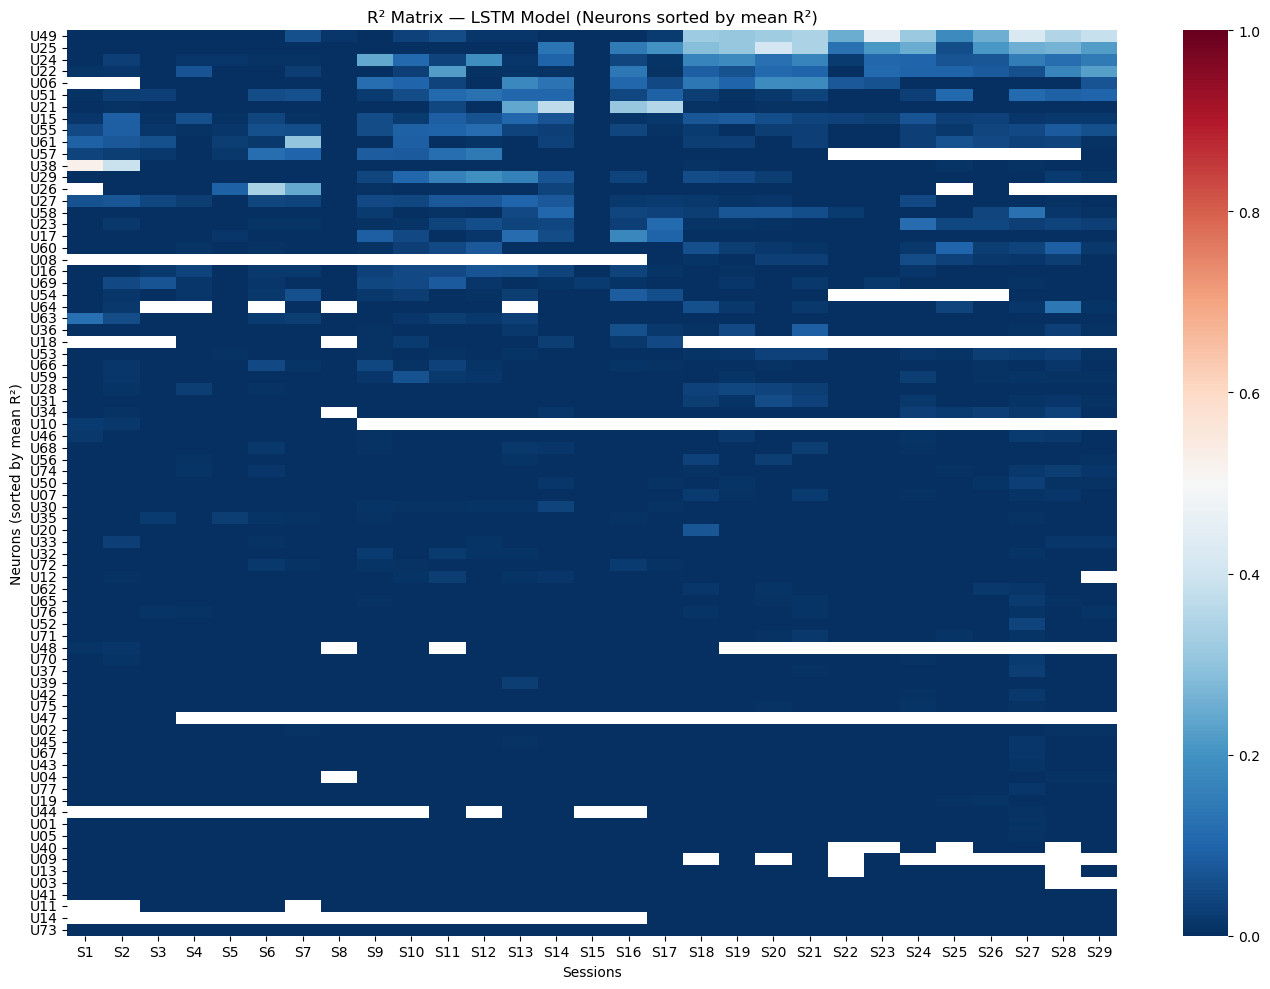

In [8]:
# ── R² heatmap ─────────────────────────────────────────────────────────────
masked_r2   = ma.array(r2_matrix, mask=mask)
neuron_mean = masked_r2.mean(axis=0).filled(np.nan)
neuron_order = np.argsort(neuron_mean)[::-1]

r2_sorted   = r2_matrix[:, neuron_order].T
mask_sorted = mask[:, neuron_order].T

plt.figure(figsize=(14, 10))
sns.heatmap(r2_sorted, mask=mask_sorted, cmap='RdBu_r', cbar=True,
            vmin=0, vmax=1,
            xticklabels=[f"S{i+1}" for i in range(num_sessions)],
            yticklabels=[f"U{neuron_order[i]+1:02d}" for i in range(num_neurons)])
plt.title('R² Matrix — LSTM Model (Neurons sorted by mean R²)')
plt.xlabel('Sessions')
plt.ylabel('Neurons (sorted by mean R²)')
plt.tight_layout()
plt.show()

In [9]:
neuron_mean.argsort()[::-1]

array([48, 24, 23, 21,  5, 50, 20, 14, 54, 60, 56, 37, 28, 25, 26, 57, 22,
       16, 59,  7, 15, 68, 53, 63, 62, 35, 17, 52, 65, 58, 27, 30, 33,  9,
       45, 67, 55, 73, 49,  6, 29, 34, 19, 32, 31, 71, 11, 61, 64, 75, 51,
       70, 47, 69, 36, 38, 41, 74, 46,  1, 44, 66, 42,  3, 76, 18, 43,  0,
        4, 39,  8, 12,  2, 40, 10, 13, 72])

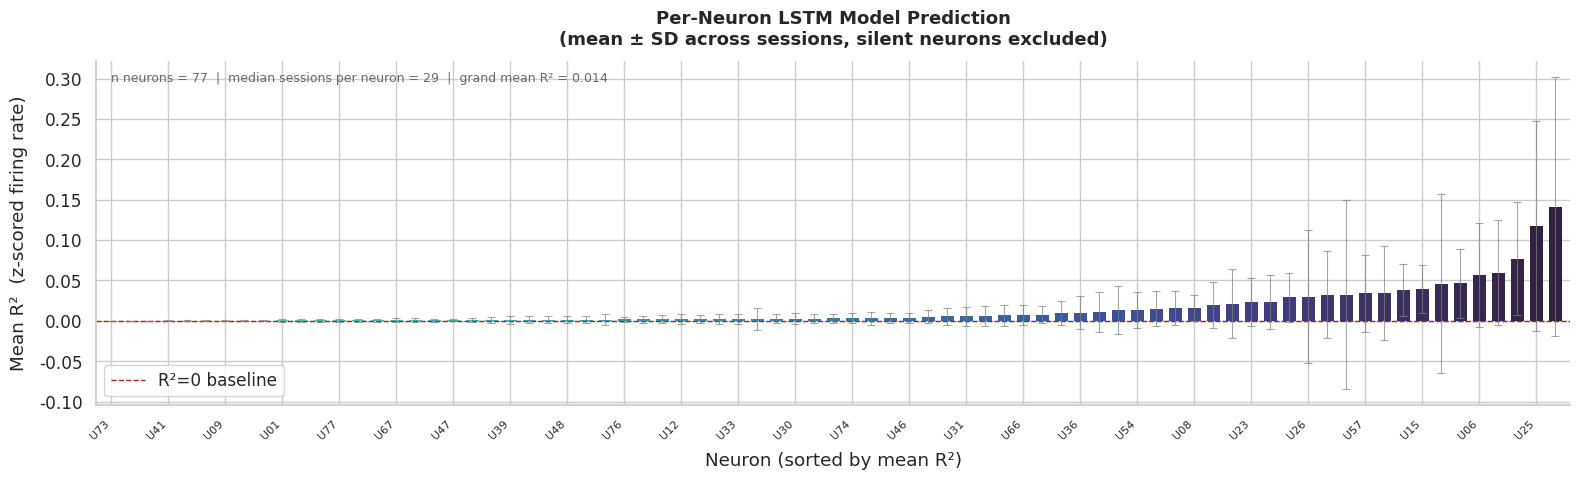

In [10]:
# ── Per-neuron R² bar chart ────────────────────────────────────────────────
r2_matrix = np.clip(r2_matrix, 0, 1)
masked_r2   = ma.array(r2_matrix, mask=mask)
neuron_mean = masked_r2.mean(axis=0).filled(np.nan)
neuron_std  = masked_r2.std(axis=0).filled(np.nan)

order    = np.argsort(neuron_mean)
x        = np.arange(num_neurons)
labels   = [f"U{i+1:02d}" for i in order]
means_s  = neuron_mean[order]
stds_s   = neuron_std[order]

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
palette  = sns.color_palette("mako_r", as_cmap=True)
colors   = palette(np.linspace(0.15, 0.85, num_neurons))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, means_s, width=0.7, color=colors, zorder=3, linewidth=0)
ax.errorbar(x, means_s, yerr=stds_s,
            fmt="none", ecolor="gray", elinewidth=0.8,
            capsize=3, capthick=0.8, zorder=4, alpha=0.7)
ax.axhline(0, color='firebrick', linestyle='--', linewidth=1, label='R²=0 baseline')

ax.set_xticks(x[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Neuron (sorted by mean R²)", labelpad=8)
ax.set_ylabel("Mean R²  (z-scored firing rate)", labelpad=8)
ax.set_title("Per-Neuron LSTM Model Prediction\n"
             "(mean ± SD across sessions, silent neurons excluded)",
             fontsize=13, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.set_xlim(-0.8, num_neurons - 0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()

valid_counts = (~mask).sum(axis=0)[order]
ax.annotate(
    f"n neurons = {num_neurons}  |  "
    f"median sessions per neuron = {int(np.median(valid_counts))}  |  "
    f"grand mean R² = {np.nanmean(neuron_mean):.3f}",
    xy=(0.01, 0.97), xycoords="axes fraction",
    va="top", ha="left", fontsize=9, color="dimgray"
)
plt.tight_layout()
plt.show()

Correlation between train-test variance discrepancy and MSE: -0.85


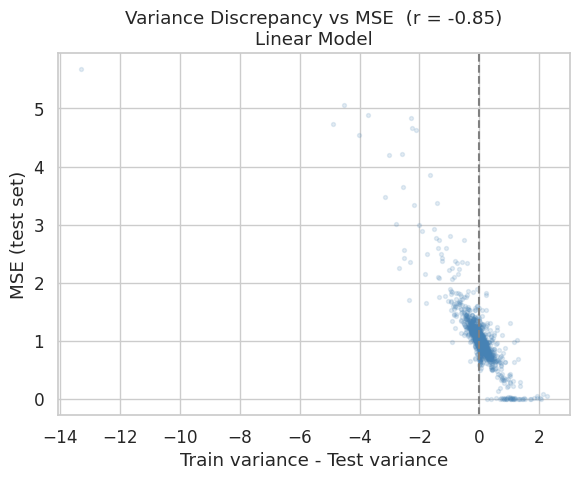

In [11]:
# ── Variance discrepancy diagnostic ───────────────────────────────────────
train_var_all, test_var_all, mse_all = [], [], []

for session_id in session_ids:
    test_idx_num   = list(session_ids).index(session_id)
    session_labels = session_dataset_singles[session_id]["labels"]
    session_mse    = mse_matrix[test_idx_num, :]
    valid_mask     = ~mask[test_idx_num, :]

    test_trial_indices  = [int(idx) for idx in test_indices_by_session[session_id]]
    all_trial_ids       = list(session_labels.keys())
    train_trial_indices = [idx for idx in all_trial_ids if idx not in test_trial_indices]

    for neuron_idx in range(num_neurons):
        if not valid_mask[neuron_idx]:
            continue
        train_var = np.mean([np.var(session_labels[idx][:, neuron_idx])
                             for idx in train_trial_indices])
        test_var  = np.mean([np.var(session_labels[idx][:, neuron_idx])
                             for idx in test_trial_indices])
        train_var_all.append(train_var)
        test_var_all.append(test_var)
        mse_all.append(session_mse[neuron_idx])

train_var_all = np.array(train_var_all)
test_var_all  = np.array(test_var_all)
mse_all       = np.array(mse_all)
discrepancy   = train_var_all - test_var_all

r_check = np.corrcoef(discrepancy, mse_all)[0, 1]
print(f"Correlation between train-test variance discrepancy and MSE: {r_check:.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(discrepancy, mse_all, alpha=0.15, s=8, color='steelblue')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Train variance - Test variance')
plt.ylabel('MSE (test set)')
plt.title(f'Variance Discrepancy vs MSE  (r = {r_check:.2f})\nLinear Model')
plt.tight_layout()
plt.show()

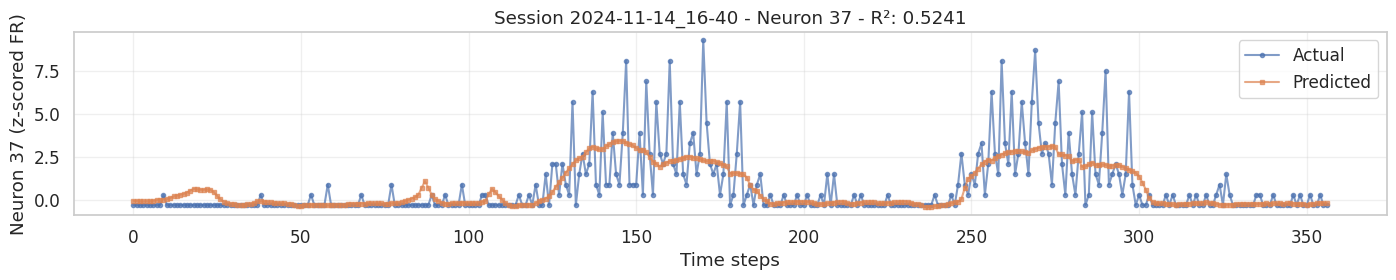

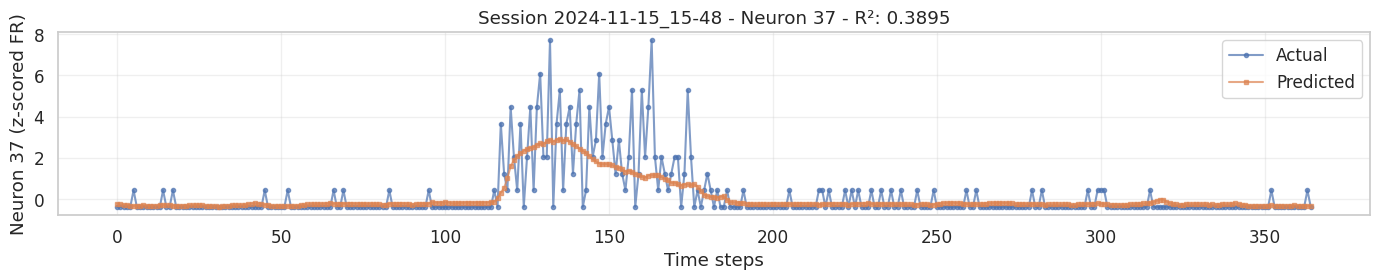

Session 2024-11-20_17-46: No valid neurons to plot
Session 2024-11-21_17-22: No valid neurons to plot
Session 2024-11-25_16-25: No valid neurons to plot


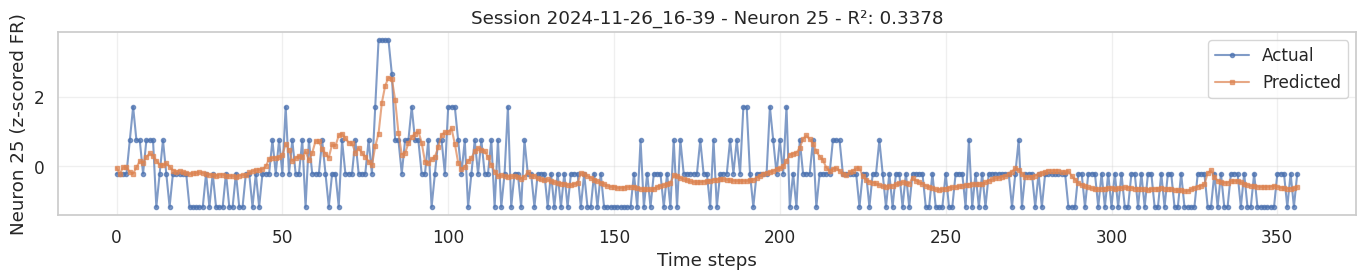

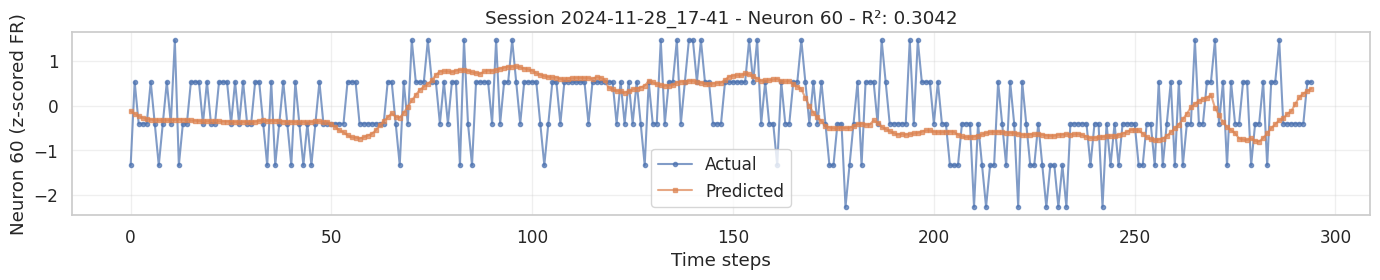

Session 2024-11-29_17-21: No valid neurons to plot
Session 2024-12-02_16-09: No valid neurons to plot
Session 2024-12-03_16-23: No valid neurons to plot
Session 2024-12-04_18-06: No valid neurons to plot
Session 2024-12-06_16-49: No valid neurons to plot
Session 2024-12-09_17-45: No valid neurons to plot


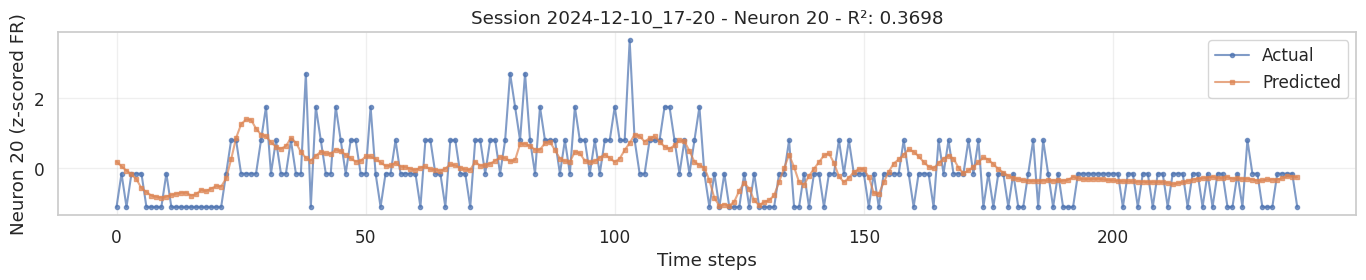

Session 2024-12-11_17-42: No valid neurons to plot


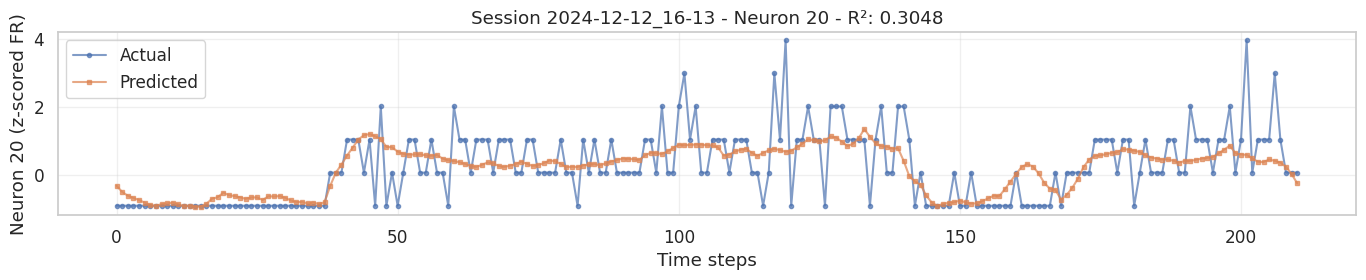

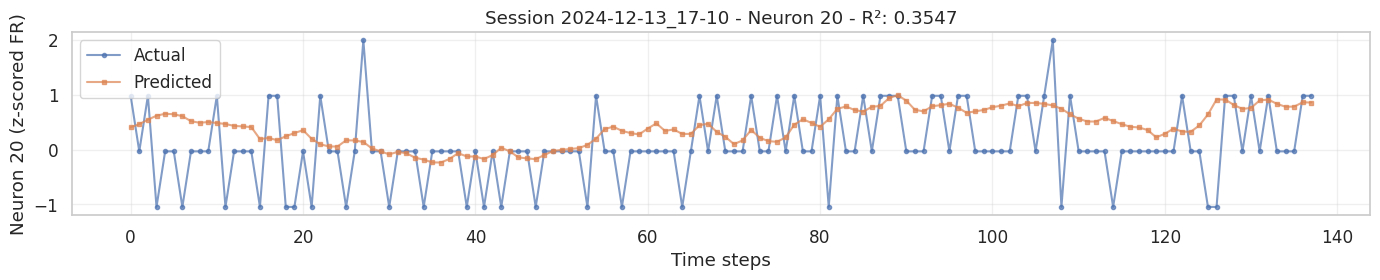

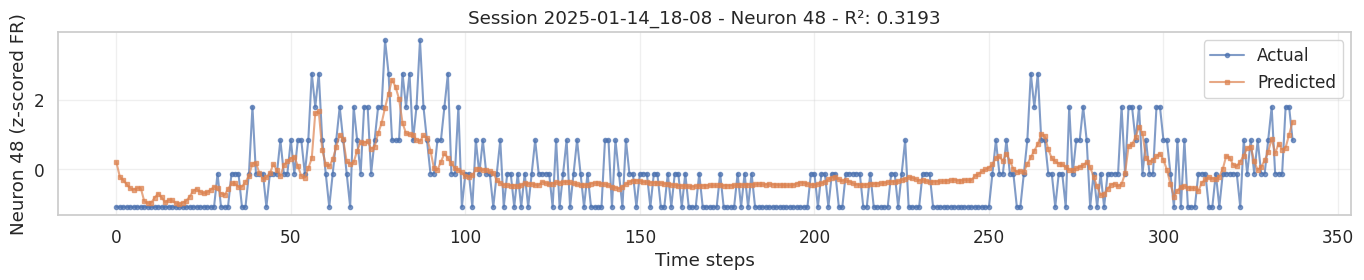

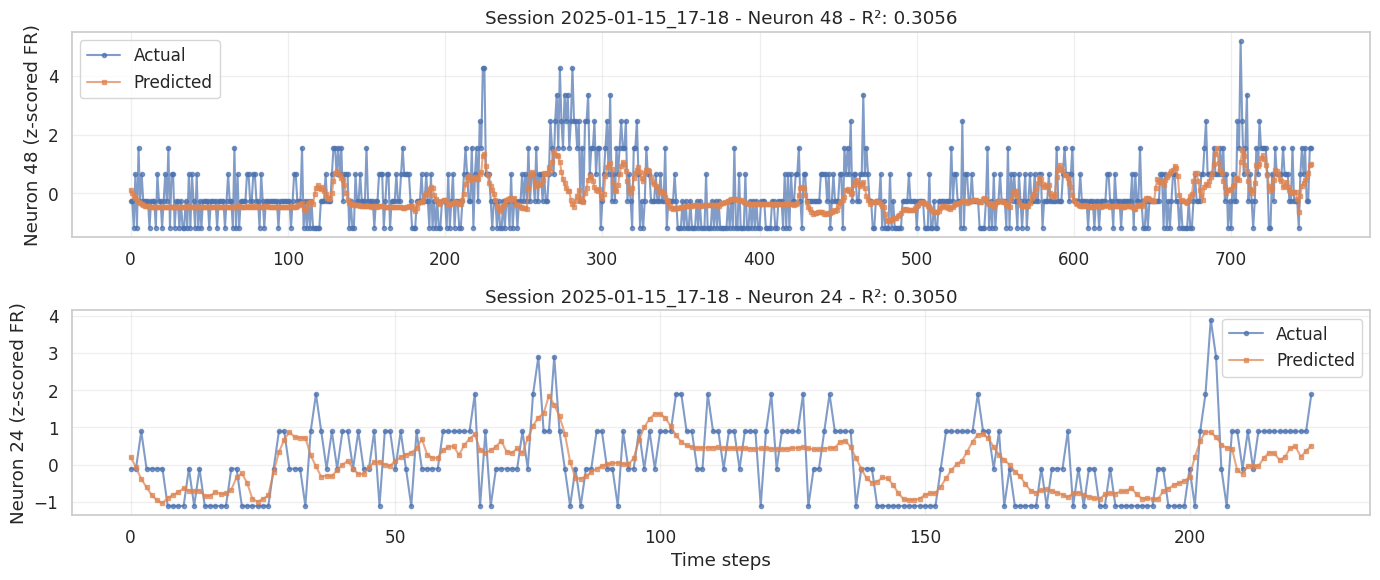

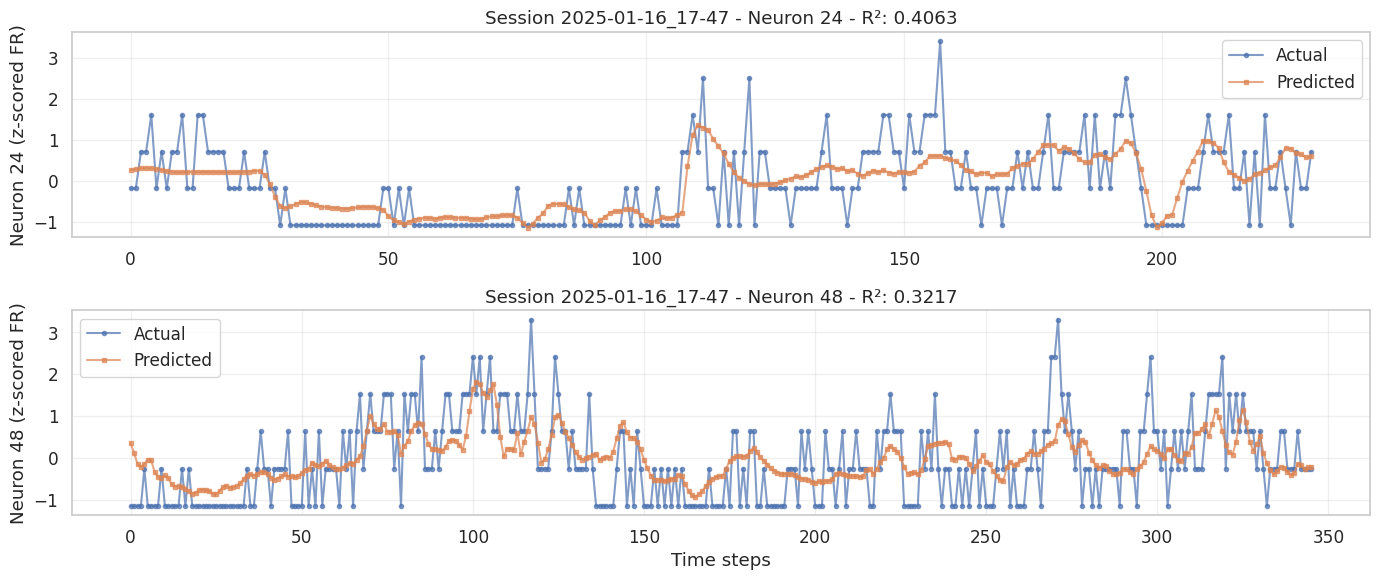

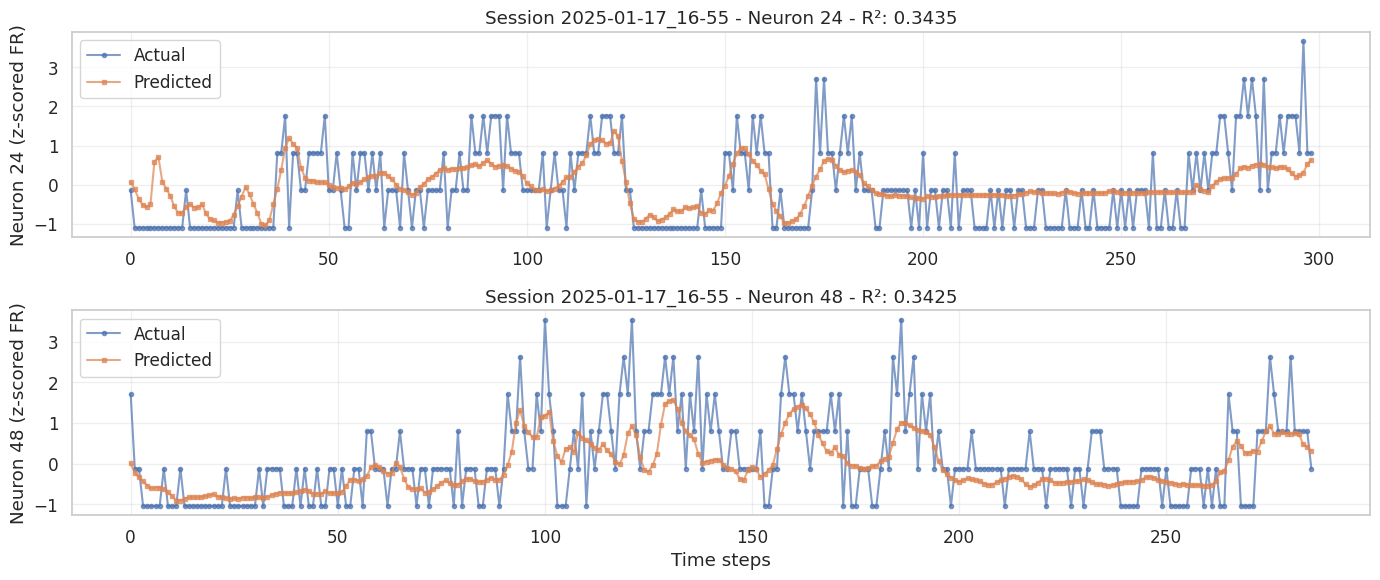

Session 2025-01-21_18-49: No valid neurons to plot


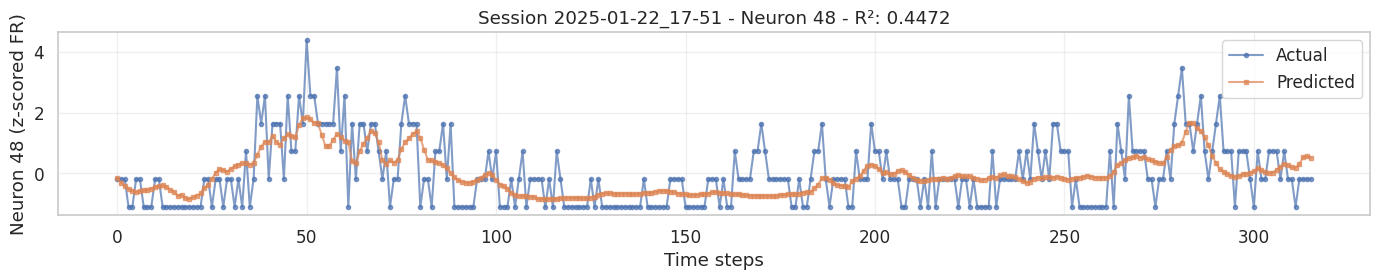

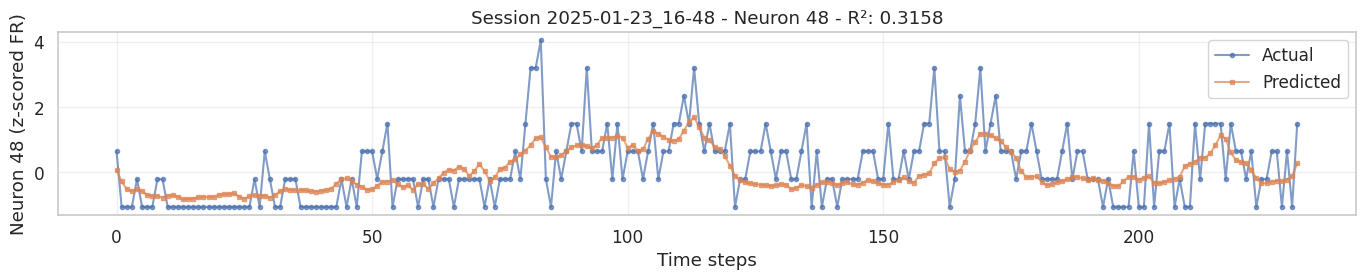

Session 2025-01-24_12-24: No valid neurons to plot
Session 2025-01-24_19-37: No valid neurons to plot


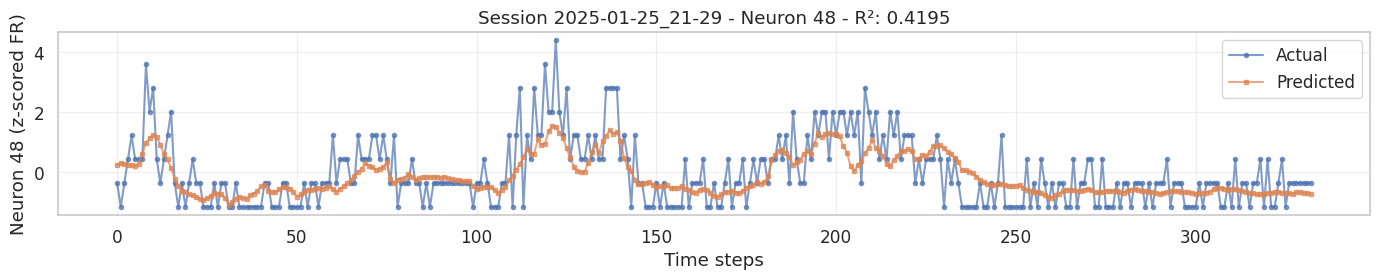

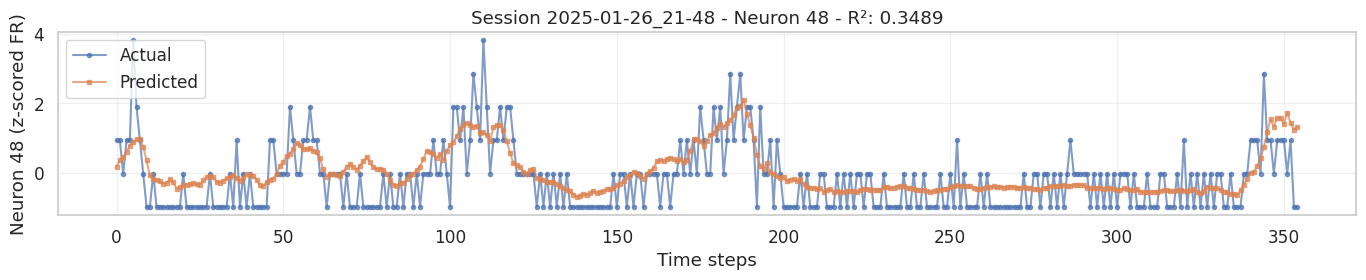

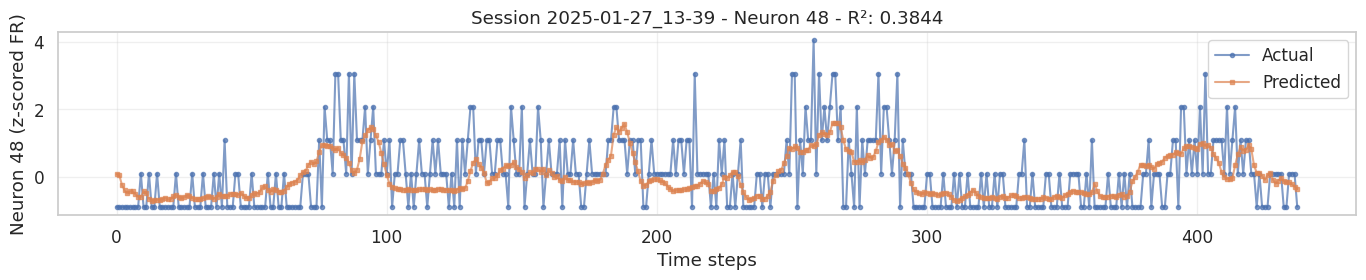

In [12]:
hidden_size = 64
num_layers = 1
window = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Iterate through all sessions and plot best neurons
test_indices_by_session = np.load("test_indices_by_session.npy", allow_pickle=True).item()

for session_id in session_ids:
    test_idx_num = list(session_ids).index(session_id)
    
    session_data = session_dataset_singles[session_id]["data"]
    session_labels = session_dataset_singles[session_id]["labels"]
    session_r2 = r2_matrix[test_idx_num, :]
    
    # Get best performing neurons (excluding masked ones)
    valid_mask = ~mask[test_idx_num, :]
    valid_neuron_indices = np.where(valid_mask)[0]
    valid_r2_values = session_r2[valid_mask]
    candidates = valid_neuron_indices[valid_r2_values >= 0.3]
    if len(candidates) > 0:
        # Sort candidates by R² descending
        sorted_candidates = candidates[np.argsort(session_r2[candidates])[::-1]]
        best_neuron_indices = sorted_candidates[:5]
    else:
        best_neuron_indices = np.array([])
    
    if len(best_neuron_indices) == 0:
        print(f"Session {session_id}: No valid neurons to plot")
        continue
    
    # Use pre-computed test indices - convert floats to ints
    test_trial_indices = [int(idx) for idx in test_indices_by_session[session_id]]
    all_trial_ids = list(session_data.keys())
    
    test_trials_data = {idx: session_data[idx] for idx in test_trial_indices if idx in session_data}
    test_labels_np = {idx: session_labels[idx] for idx in test_trial_indices if idx in session_data}
    
    if not test_trials_data:
        print(f"Session {session_id}: No valid test trials")
        continue
    
    # Plot predictions vs actual for best neurons
    fig, axes = plt.subplots(len(best_neuron_indices), 1, figsize=(14, 3 * len(best_neuron_indices)))
    if len(best_neuron_indices) == 1:
        axes = [axes]
    
    for plot_idx, neuron_idx in enumerate(best_neuron_indices):
        model_path = os.path.join(models_dir, f"session_{test_idx_num:02d}_neuron_{neuron_idx:02d}.pt")
        model = NeuronLSTM(input_size, hidden_size, num_layers, output_size).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        
        # Pick a random trial from the test set
        random_trial_idx = random.choice(list(test_trials_data.keys()))
        trial_data = test_trials_data[random_trial_idx]
        trial_labels = test_labels_np[random_trial_idx]

        X_list, y_list = [], []
        T      = len(trial_data)
        padded = np.zeros((window - 1 + T, trial_data.shape[1]), dtype=np.float32)
        padded[window - 1:] = trial_data
        for t in range(T):
            X_list.append(padded[t: t + window])   # (window, input_size)

        X_np = np.stack(X_list)
        
        with torch.no_grad():
            test_data_tensor = torch.tensor(X_np, dtype=torch.float32).to(device)
            predictions = model(test_data_tensor)
            predictions_np = predictions.squeeze().cpu().numpy()
        
        ax = axes[plot_idx]
        time_steps = np.arange(len(trial_labels))
        ax.plot(time_steps, trial_labels[:, neuron_idx], 'o-', label='Actual', alpha=0.7, markersize=3)
        ax.plot(time_steps, predictions_np, 's-', label='Predicted', alpha=0.7, markersize=3)
        ax.set_ylabel(f'Neuron {neuron_idx:02d} (z-scored FR)')
        ax.set_title(f'Session {session_id} - Neuron {neuron_idx:02d} - R²: {session_r2[neuron_idx]:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        if plot_idx == len(best_neuron_indices) - 1:
            ax.set_xlabel('Time steps')
        
        del model
        torch.cuda.empty_cache()
    
    plt.tight_layout()
    plt.show()
